<a href="https://colab.research.google.com/github/MehemmedTagizade/Thesis_Automated-Investigation-of-Cyber-Attacks-Through-Network-Traffic-Analysis-PCAPs-/blob/TEST-CODES/Copy_of_FWA_DDos_ISOLATION_F_RED_FEA_10_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the dataset
file_path = '/content/drive/MyDrive/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
data = pd.read_csv(file_path)


In [4]:



print(data.columns)  # See the actual column names


Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [5]:
data.rename(columns=lambda x: x.strip(), inplace=True)


In [6]:

print(data.columns)


Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [7]:







import pandas as pd

# Load your dataset (replace 'your_dataset.csv' with the actual filename)


# Check if "Label" column exists
if "Label" in data.columns:
    unique_labels = data["Label"].unique()
    print(f"Unique values in 'Label' column: {unique_labels}")
    print(f"Number of unique values: {len(unique_labels)}")
else:
    print("No 'Label' column found in this dataset.")
# Count occurrences of each label
label_counts = data["Label"].value_counts()

# Convert to percentages
label_percentages = (label_counts / label_counts.sum()) * 100

# Display the results
print(label_percentages)



Unique values in 'Label' column: ['BENIGN' 'DDoS']
Number of unique values: 2
Label
DDoS      56.713105
BENIGN    43.286895
Name: count, dtype: float64


In [8]:

# Clean column names by removing extra spaces
data.columns = data.columns.str.replace(' ', '')
print(data.columns)

Index(['DestinationPort', 'FlowDuration', 'TotalFwdPackets',
       'TotalBackwardPackets', 'TotalLengthofFwdPackets',
       'TotalLengthofBwdPackets', 'FwdPacketLengthMax', 'FwdPacketLengthMin',
       'FwdPacketLengthMean', 'FwdPacketLengthStd', 'BwdPacketLengthMax',
       'BwdPacketLengthMin', 'BwdPacketLengthMean', 'BwdPacketLengthStd',
       'FlowBytes/s', 'FlowPackets/s', 'FlowIATMean', 'FlowIATStd',
       'FlowIATMax', 'FlowIATMin', 'FwdIATTotal', 'FwdIATMean', 'FwdIATStd',
       'FwdIATMax', 'FwdIATMin', 'BwdIATTotal', 'BwdIATMean', 'BwdIATStd',
       'BwdIATMax', 'BwdIATMin', 'FwdPSHFlags', 'BwdPSHFlags', 'FwdURGFlags',
       'BwdURGFlags', 'FwdHeaderLength', 'BwdHeaderLength', 'FwdPackets/s',
       'BwdPackets/s', 'MinPacketLength', 'MaxPacketLength',
       'PacketLengthMean', 'PacketLengthStd', 'PacketLengthVariance',
       'FINFlagCount', 'SYNFlagCount', 'RSTFlagCount', 'PSHFlagCount',
       'ACKFlagCount', 'URGFlagCount', 'CWEFlagCount', 'ECEFlagCount',
       '

In [9]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

# Display the first 10 rows of the dataset
print("First 10 rows of the dataset:")
print(data.head(10))



First 10 rows of the dataset:
   DestinationPort  FlowDuration  TotalFwdPackets  TotalBackwardPackets  \
0            54865             3                2                     0   
1            55054           109                1                     1   
2            55055            52                1                     1   
3            46236            34                1                     1   
4            54863             3                2                     0   
5            54871          1022                2                     0   
6            54925             4                2                     0   
7            54925            42                1                     1   
8             9282             4                2                     0   
9            55153             4                2                     0   

   TotalLengthofFwdPackets  TotalLengthofBwdPackets  FwdPacketLengthMax  \
0                       12                        0                  

In [10]:
print(data.isnull().sum())


DestinationPort            0
FlowDuration               0
TotalFwdPackets            0
TotalBackwardPackets       0
TotalLengthofFwdPackets    0
                          ..
IdleMean                   0
IdleStd                    0
IdleMax                    0
IdleMin                    0
Label                      0
Length: 79, dtype: int64


In [11]:
print(data['Label'].value_counts())


Label
DDoS      128025
BENIGN     97686
Name: count, dtype: int64


In [12]:
irrelevant_columns = [
    'FwdPSHFlags', 'BwdPSHFlags', 'FwdURGFlags', 'BwdURGFlags',
    'CWEFlagCount', 'ECEFlagCount', 'FwdHeaderLength.1',
    'FwdAvgBytes/Bulk', 'FwdAvgPackets/Bulk', 'FwdAvgBulkRate',
    'BwdAvgBytes/Bulk', 'BwdAvgPackets/Bulk', 'BwdAvgBulkRate',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
    'SubflowFwdPackets', 'SubflowFwdBytes', 'SubflowBwdPackets', 'SubflowBwdBytes',
    'ActiveMean', 'ActiveStd', 'ActiveMax', 'ActiveMin',
    'IdleMean', 'IdleStd', 'IdleMax', 'IdleMin'
]

data = data.drop(columns=irrelevant_columns, errors='ignore')
print(data.columns)
print(len(data.columns))

Index(['DestinationPort', 'FlowDuration', 'TotalFwdPackets',
       'TotalBackwardPackets', 'TotalLengthofFwdPackets',
       'TotalLengthofBwdPackets', 'FwdPacketLengthMax', 'FwdPacketLengthMin',
       'FwdPacketLengthMean', 'FwdPacketLengthStd', 'BwdPacketLengthMax',
       'BwdPacketLengthMin', 'BwdPacketLengthMean', 'BwdPacketLengthStd',
       'FlowBytes/s', 'FlowPackets/s', 'FlowIATMean', 'FlowIATStd',
       'FlowIATMax', 'FlowIATMin', 'FwdIATTotal', 'FwdIATMean', 'FwdIATStd',
       'FwdIATMax', 'FwdIATMin', 'BwdIATTotal', 'BwdIATMean', 'BwdIATStd',
       'BwdIATMax', 'BwdIATMin', 'FwdHeaderLength', 'BwdHeaderLength',
       'FwdPackets/s', 'BwdPackets/s', 'MinPacketLength', 'MaxPacketLength',
       'PacketLengthMean', 'PacketLengthStd', 'PacketLengthVariance',
       'FINFlagCount', 'SYNFlagCount', 'RSTFlagCount', 'PSHFlagCount',
       'ACKFlagCount', 'URGFlagCount', 'Down/UpRatio', 'AveragePacketSize',
       'AvgFwdSegmentSize', 'AvgBwdSegmentSize', 'act_data_pkt_fwd',
 

In [13]:
begnin_count = data[data['Label'] == 'BENIGN'].shape[0]
print(f"Number of BENIGN samples: {begnin_count}")

ddos_count = data[data['Label'] == 'DDoS'].shape[0]
print(f"Number of DDoS samples: {ddos_count}")

Number of BENIGN samples: 97686
Number of DDoS samples: 128025


In [14]:
from math import floor
benign_samples = data[data['Label'] == 'BENIGN']
percentage = 0.1
malicious_samples = data[data['Label'] == 'DDoS'].sample(n=floor((begnin_count*percentage)/(1-percentage)), random_state=42)

# Combine the sampled data
data = pd.concat([benign_samples, malicious_samples])

# Shuffle the data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [15]:
print(data['Label'].value_counts())


Label
BENIGN    97686
DDoS      10854
Name: count, dtype: int64


In [16]:
# Calculate the correlation matrix, ignoring non-numerical columns
correlation_matrix = data.select_dtypes(include=[np.number]).corr()

# Find highly correlated features (e.g., with correlation > 0.9)
high_corr = correlation_matrix[correlation_matrix > 0.9]
print(high_corr)


                         DestinationPort  FlowDuration  TotalFwdPackets  \
DestinationPort                      1.0           NaN              NaN   
FlowDuration                         NaN       1.00000              NaN   
TotalFwdPackets                      NaN           NaN         1.000000   
TotalBackwardPackets                 NaN           NaN         0.964653   
TotalLengthofFwdPackets              NaN           NaN              NaN   
TotalLengthofBwdPackets              NaN           NaN         0.949403   
FwdPacketLengthMax                   NaN           NaN              NaN   
FwdPacketLengthMin                   NaN           NaN              NaN   
FwdPacketLengthMean                  NaN           NaN              NaN   
FwdPacketLengthStd                   NaN           NaN              NaN   
BwdPacketLengthMax                   NaN           NaN              NaN   
BwdPacketLengthMin                   NaN           NaN              NaN   
BwdPacketLengthMean      

In [17]:
from sklearn.model_selection import train_test_split
X = data.drop('Label', axis=1)
y = data['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")


Training set size: 86832, Test set size: 21708


In [18]:
# Separate features and labels
features = data.drop('Label', axis=1)
labels = data['Label']
features.replace([np.inf, -np.inf], np.nan, inplace=True)
features.dropna(inplace=True)
features = features.select_dtypes(include=[float, int])
len(features)

108540

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)

In [21]:
round(data.shape[0]*80/100)

86832

In [22]:

missing_labels = np.isnan(y_encoded).sum()
print(f"Number of missing values in y_encoded: {missing_labels}")

Number of missing values in y_encoded: 0


In [23]:
train_size = round(len(y_encoded) * 0.9)

X_train = features_scaled[:train_size]
X_test = features_scaled[train_size:]
y_train = y_encoded[:train_size]
y_test = y_encoded[train_size:]

print(f"Length of X_train: {len(X_train)}")
print(f"Length of y_train: {len(y_train)}")
print(f"Length of X_test: {len(X_test)}")
print(f"Length of y_test: {len(y_test)}")

min_len = min(len(X_test), len(y_test))
X_test = X_test[:min_len]
y_test = y_test[:min_len]

print(f"Final Length of X_test: {len(X_test)}")
print(f"Final Length of y_test: {len(y_test)}")


Length of X_train: 97686
Length of y_train: 97686
Length of X_test: 10854
Length of y_test: 10854
Final Length of X_test: 10854
Final Length of y_test: 10854


In [24]:
# ----------- 5-Fold Cross-Validation for Isolation Forest -----------
from sklearn.model_selection import KFold
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_reports = []

print("Starting 5-Fold Cross-Validation for Isolation Forest...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(features_scaled)):
    X_train_cv, X_val_cv = features_scaled[train_idx], features_scaled[val_idx]
    y_val_cv = y_encoded[val_idx]

    model = IsolationForest(contamination=0.1, random_state=42)
    model.fit(X_train_cv)

    preds = model.predict(X_val_cv)
    preds = np.where(preds == -1, 1, 0)

    print(f"\nFold {fold + 1} Report:")
    print(classification_report(y_val_cv, preds))

    all_reports.append(classification_report(y_val_cv, preds, output_dict=True))

# Average F1-score across all folds
avg_f1 = np.mean([r['weighted avg']['f1-score'] for r in all_reports])
print(f"\nAverage Weighted F1-Score (5 folds): {avg_f1:.4f}")
# --------------------------------------------------------------------


Starting 5-Fold Cross-Validation for Isolation Forest...


Fold 1 Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     19544
           1       0.11      0.12      0.11      2164

    accuracy                           0.82     21708
   macro avg       0.51      0.51      0.51     21708
weighted avg       0.82      0.82      0.82     21708


Fold 2 Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     19484
           1       0.16      0.15      0.16      2224

    accuracy                           0.83     21708
   macro avg       0.53      0.53      0.53     21708
weighted avg       0.83      0.83      0.83     21708


Fold 3 Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     19590
           1       0.14      0.14      0.14      2118

    accuracy                           0.83     21708
   macro avg       0.5

Starting 5-Fold Cross-Validation for Isolation Forest...


Fold 1 Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     19544
           1       0.11      0.12      0.11      2164

    accuracy                           0.82     21708
   macro avg       0.51      0.51      0.51     21708
weighted avg       0.82      0.82      0.82     21708



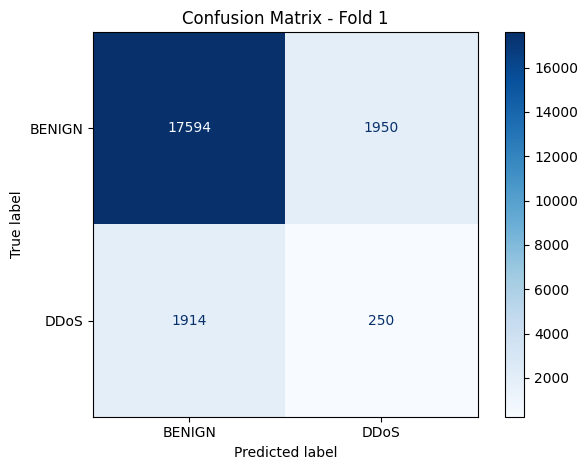


Fold 2 Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     19484
           1       0.16      0.15      0.16      2224

    accuracy                           0.83     21708
   macro avg       0.53      0.53      0.53     21708
weighted avg       0.83      0.83      0.83     21708



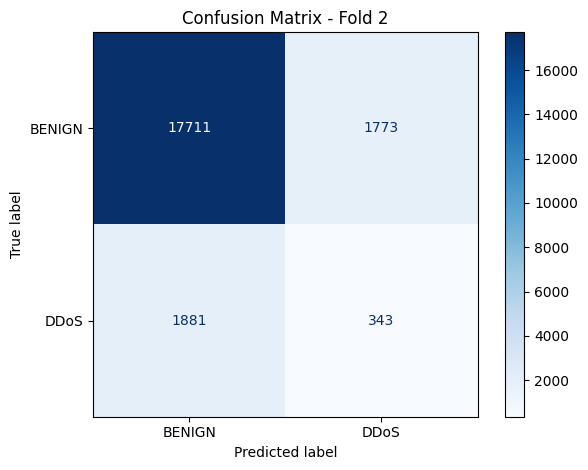


Fold 3 Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     19590
           1       0.14      0.14      0.14      2118

    accuracy                           0.83     21708
   macro avg       0.52      0.52      0.52     21708
weighted avg       0.83      0.83      0.83     21708



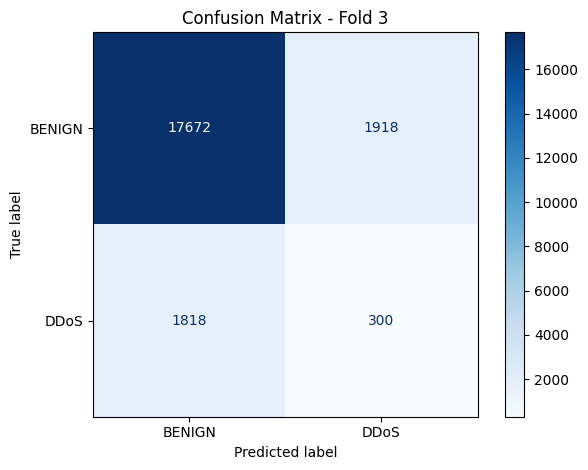


Fold 4 Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     19573
           1       0.14      0.14      0.14      2135

    accuracy                           0.83     21708
   macro avg       0.52      0.52      0.52     21708
weighted avg       0.83      0.83      0.83     21708



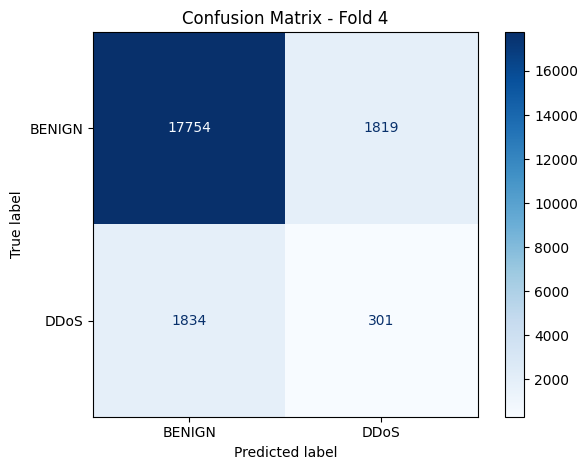


Fold 5 Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     19495
           1       0.15      0.15      0.15      2213

    accuracy                           0.83     21708
   macro avg       0.53      0.53      0.53     21708
weighted avg       0.83      0.83      0.83     21708



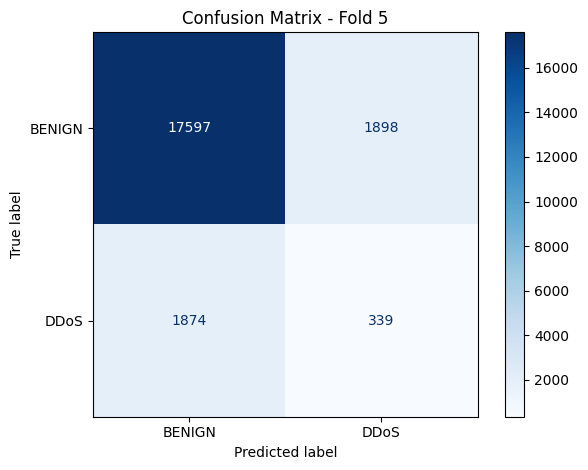


Average Weighted F1-Score (5 folds): 0.8280


In [25]:
from sklearn.model_selection import KFold
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_reports = []

print("Starting 5-Fold Cross-Validation for Isolation Forest...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(features_scaled)):
    X_train_cv, X_val_cv = features_scaled[train_idx], features_scaled[val_idx]
    y_val_cv = y_encoded[val_idx]

    model = IsolationForest(contamination=0.1, random_state=42)
    model.fit(X_train_cv)

    preds = model.predict(X_val_cv)
    preds = np.where(preds == -1, 1, 0)  # Convert -1 to 1 (anomaly), 1 to 0 (normal)

    print(f"\nFold {fold + 1} Report:")
    print(classification_report(y_val_cv, preds))

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_val_cv, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BENIGN', 'DDoS'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()
    plt.show()
    # --------------------------

    all_reports.append(classification_report(y_val_cv, preds, output_dict=True))

# Average Weighted F1-score across all folds
avg_f1 = np.mean([r['weighted avg']['f1-score'] for r in all_reports])
print(f"\nAverage Weighted F1-Score (5 folds): {avg_f1:.4f}")


Starting 5-Fold Cross-Validation for Isolation Forest...


Fold 1 Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     19544
           1       0.11      0.12      0.12      2164

    accuracy                           0.82     21708
   macro avg       0.51      0.51      0.51     21708
weighted avg       0.82      0.82      0.82     21708



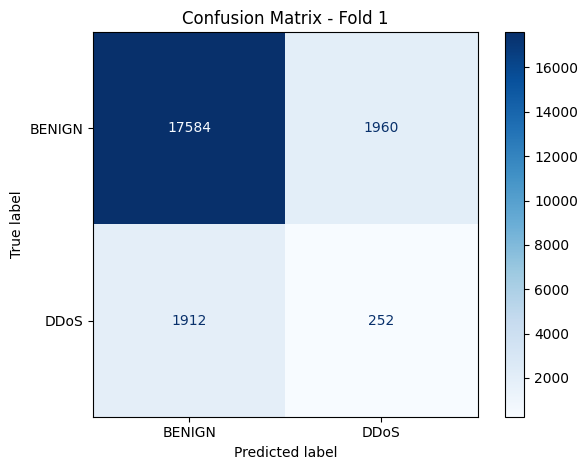


Fold 2 Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     19484
           1       0.16      0.15      0.15      2224

    accuracy                           0.83     21708
   macro avg       0.53      0.53      0.53     21708
weighted avg       0.83      0.83      0.83     21708



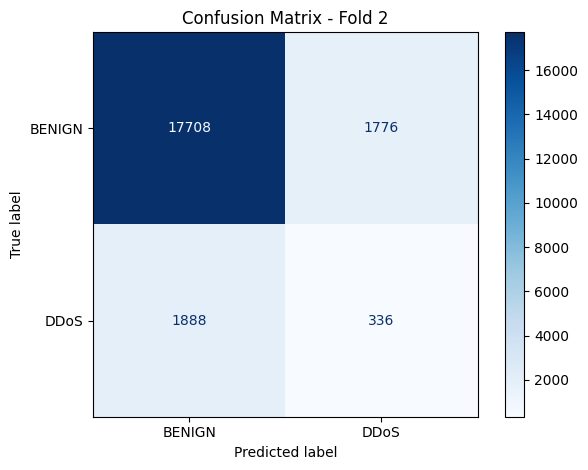


Fold 3 Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     19590
           1       0.14      0.14      0.14      2118

    accuracy                           0.83     21708
   macro avg       0.52      0.52      0.52     21708
weighted avg       0.83      0.83      0.83     21708



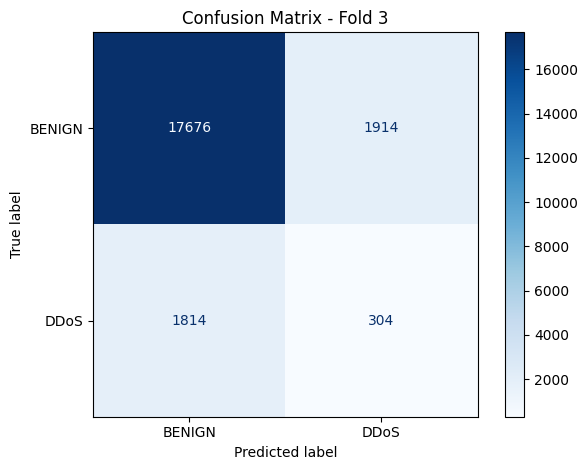


Fold 4 Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     19573
           1       0.14      0.14      0.14      2135

    accuracy                           0.83     21708
   macro avg       0.52      0.52      0.52     21708
weighted avg       0.83      0.83      0.83     21708



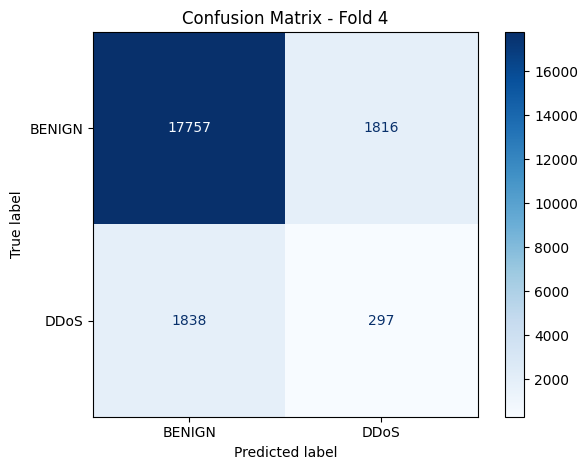


Fold 5 Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     19495
           1       0.15      0.16      0.16      2213

    accuracy                           0.83     21708
   macro avg       0.53      0.53      0.53     21708
weighted avg       0.83      0.83      0.83     21708



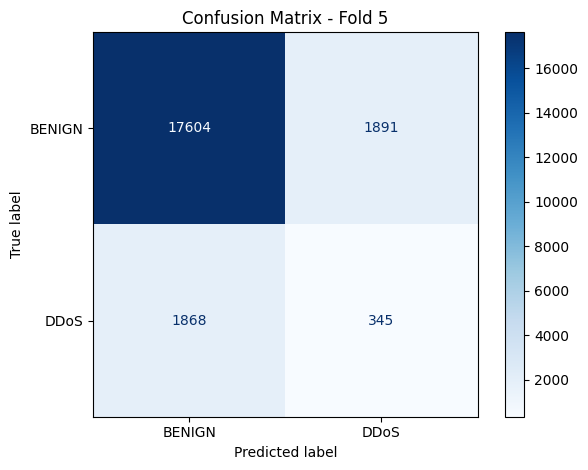


=== Average Scores Over 5 Folds ===
Average Weighted Precision: 0.8282
Average Weighted Recall:    0.8279
Average Weighted F1-Score:  0.8281


In [26]:
from sklearn.model_selection import KFold
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_reports = []

print("Starting 5-Fold Cross-Validation for Isolation Forest...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(features_scaled)):
    # Split data
    X_train_cv, X_val_cv = features_scaled[train_idx], features_scaled[val_idx]
    y_val_cv = y_encoded[val_idx]

    # Apply scaling (optional if already scaled, but best practice inside CV loop)
    scaler = StandardScaler()
    X_train_cv = scaler.fit_transform(X_train_cv)
    X_val_cv = scaler.transform(X_val_cv)

    # Train Isolation Forest
    model = IsolationForest(contamination=0.1, random_state=42)
    model.fit(X_train_cv)

    # Predict and map output
    preds = model.predict(X_val_cv)
    preds = np.where(preds == -1, 1, 0)  # -1 = anomaly → 1, 1 = normal → 0

    # Evaluation
    print(f"\nFold {fold + 1} Report:")
    print(classification_report(y_val_cv, preds))

    # Confusion Matrix
    cm = confusion_matrix(y_val_cv, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BENIGN', 'DDoS'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    # Save metrics
    all_reports.append(classification_report(y_val_cv, preds, output_dict=True))

# === Average Scores Across All Folds ===
avg_precision = np.mean([r['weighted avg']['precision'] for r in all_reports])
avg_recall = np.mean([r['weighted avg']['recall'] for r in all_reports])
avg_f1 = np.mean([r['weighted avg']['f1-score'] for r in all_reports])

print("\n=== Average Scores Over 5 Folds ===")
print(f"Average Weighted Precision: {avg_precision:.4f}")
print(f"Average Weighted Recall:    {avg_recall:.4f}")
print(f"Average Weighted F1-Score:  {avg_f1:.4f}")


DONE++++



=== 5-Fold CV with Contamination = 0.03 ===

Fold 1 Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     19544
           1       0.09      0.03      0.04      2164

    accuracy                           0.87     21708
   macro avg       0.49      0.50      0.49     21708
weighted avg       0.82      0.87      0.84     21708



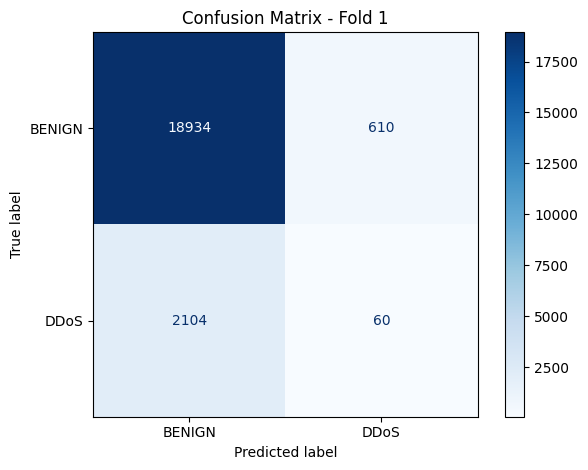


Fold 2 Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     19484
           1       0.13      0.04      0.06      2224

    accuracy                           0.88     21708
   macro avg       0.51      0.50      0.50     21708
weighted avg       0.82      0.88      0.84     21708



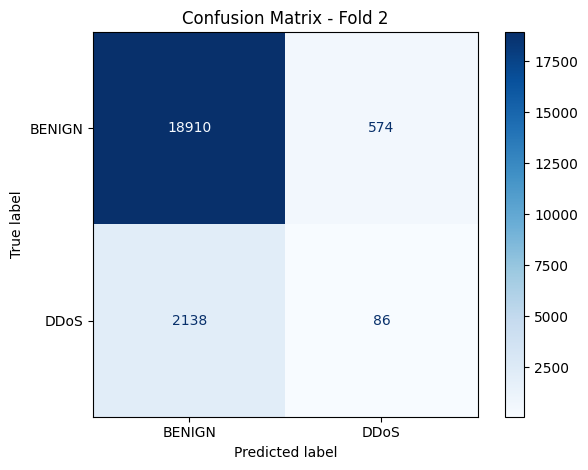


Fold 3 Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     19590
           1       0.09      0.03      0.05      2118

    accuracy                           0.88     21708
   macro avg       0.50      0.50      0.49     21708
weighted avg       0.82      0.88      0.85     21708



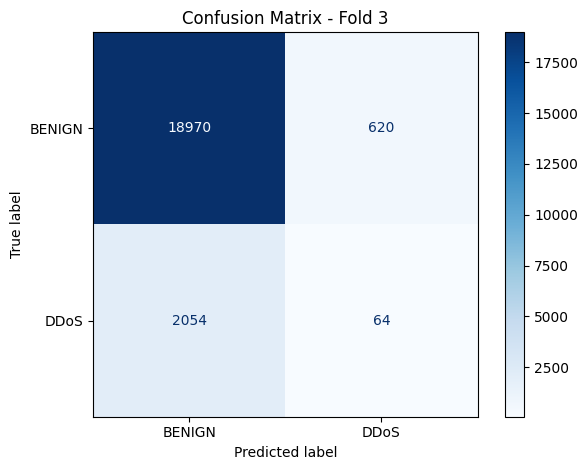


Fold 4 Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94     19573
           1       0.12      0.03      0.05      2135

    accuracy                           0.88     21708
   macro avg       0.51      0.50      0.49     21708
weighted avg       0.83      0.88      0.85     21708



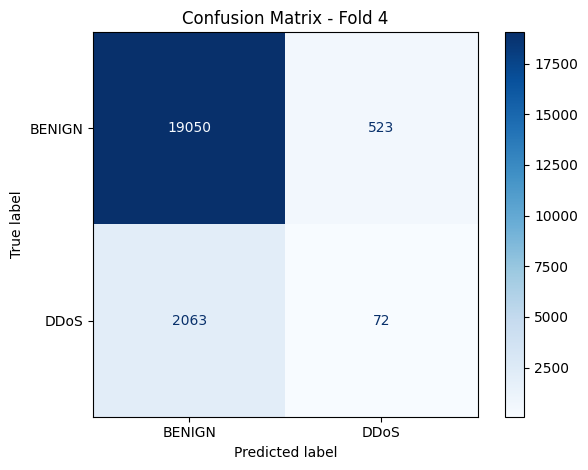


Fold 5 Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     19495
           1       0.10      0.03      0.04      2213

    accuracy                           0.87     21708
   macro avg       0.50      0.50      0.49     21708
weighted avg       0.82      0.87      0.84     21708



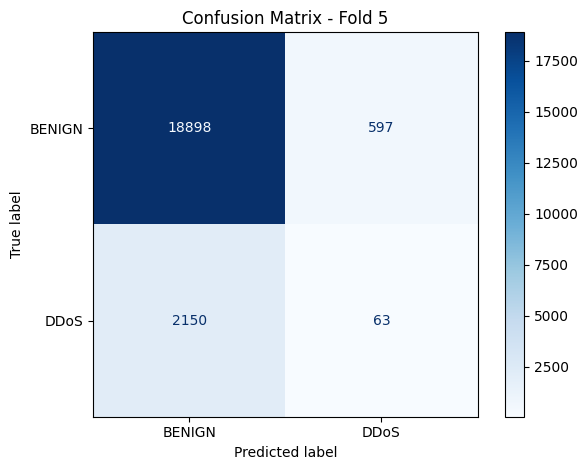


[Contamination 0.03] Avg Precision: 0.8208, Avg Recall: 0.8762, Avg F1: 0.8453

=== 5-Fold CV with Contamination = 0.05 ===

Fold 1 Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     19544
           1       0.11      0.06      0.08      2164

    accuracy                           0.86     21708
   macro avg       0.51      0.50      0.50     21708
weighted avg       0.82      0.86      0.84     21708



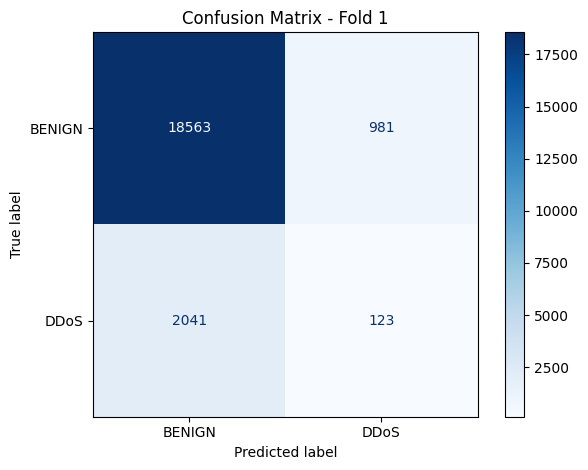


Fold 2 Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93     19484
           1       0.15      0.07      0.10      2224

    accuracy                           0.86     21708
   macro avg       0.52      0.51      0.51     21708
weighted avg       0.82      0.86      0.84     21708



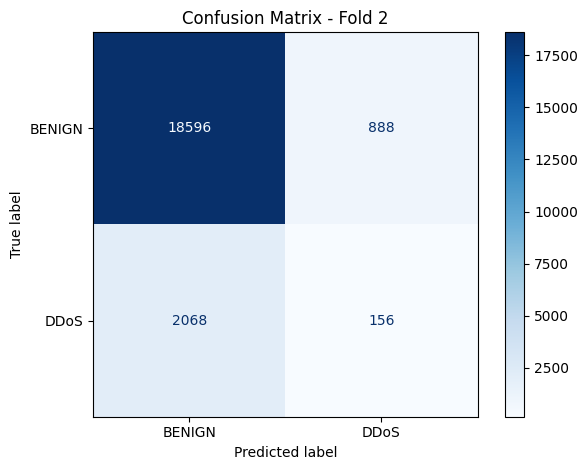


Fold 3 Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     19590
           1       0.10      0.05      0.07      2118

    accuracy                           0.86     21708
   macro avg       0.50      0.50      0.50     21708
weighted avg       0.82      0.86      0.84     21708



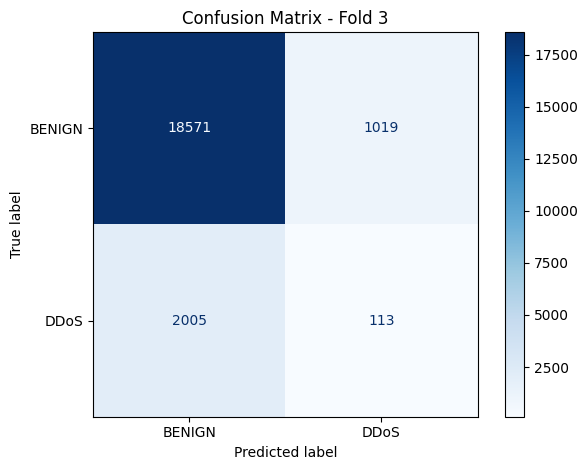


Fold 4 Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93     19573
           1       0.13      0.06      0.09      2135

    accuracy                           0.87     21708
   macro avg       0.52      0.51      0.51     21708
weighted avg       0.83      0.87      0.85     21708



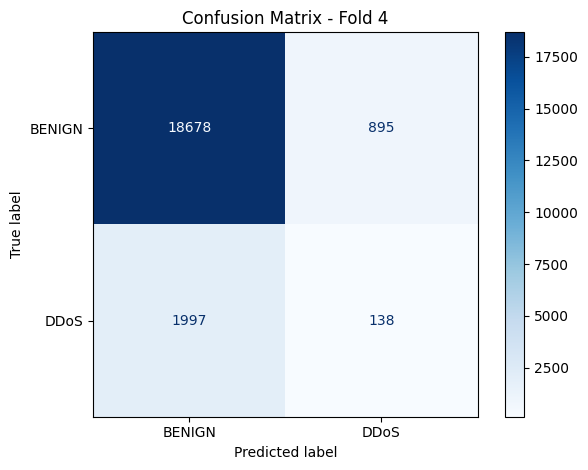


Fold 5 Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     19495
           1       0.13      0.07      0.09      2213

    accuracy                           0.86     21708
   macro avg       0.51      0.51      0.50     21708
weighted avg       0.82      0.86      0.84     21708



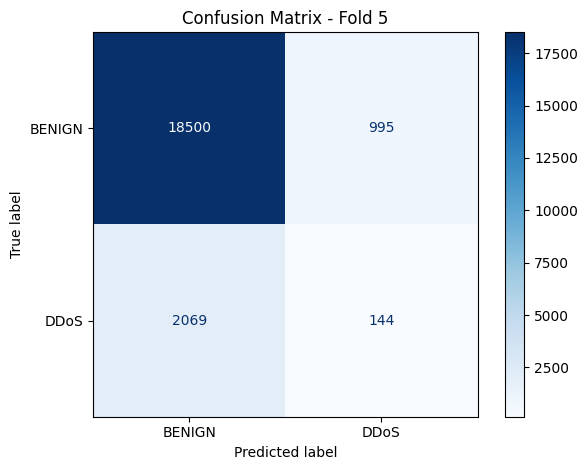


[Contamination 0.05] Avg Precision: 0.8236, Avg Recall: 0.8622, Avg F1: 0.8412

=== 5-Fold CV with Contamination = 0.07 ===

Fold 1 Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92     19544
           1       0.12      0.09      0.10      2164

    accuracy                           0.85     21708
   macro avg       0.51      0.51      0.51     21708
weighted avg       0.82      0.85      0.84     21708



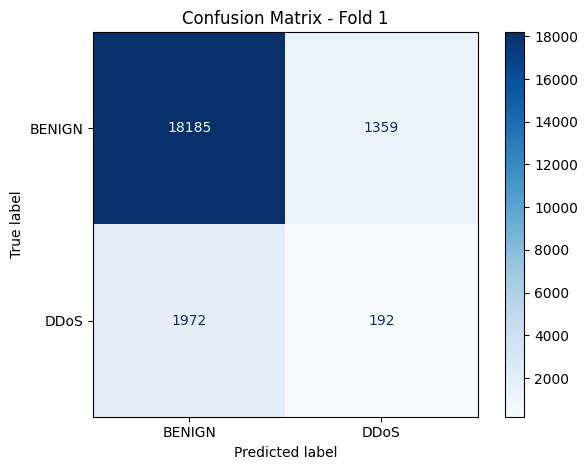


Fold 2 Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     19484
           1       0.17      0.11      0.13      2224

    accuracy                           0.85     21708
   macro avg       0.53      0.52      0.53     21708
weighted avg       0.83      0.85      0.84     21708



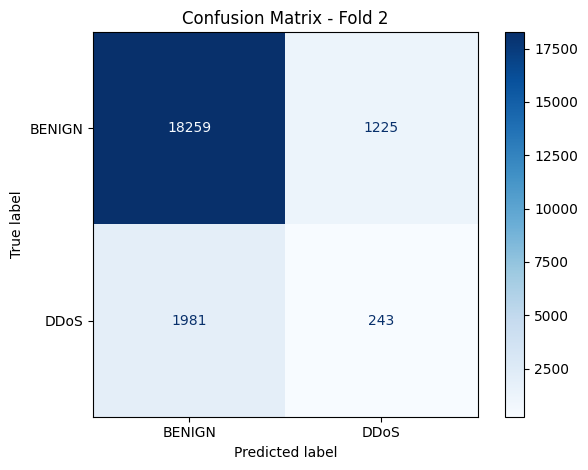


Fold 3 Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92     19590
           1       0.11      0.08      0.09      2118

    accuracy                           0.85     21708
   macro avg       0.51      0.50      0.50     21708
weighted avg       0.83      0.85      0.84     21708



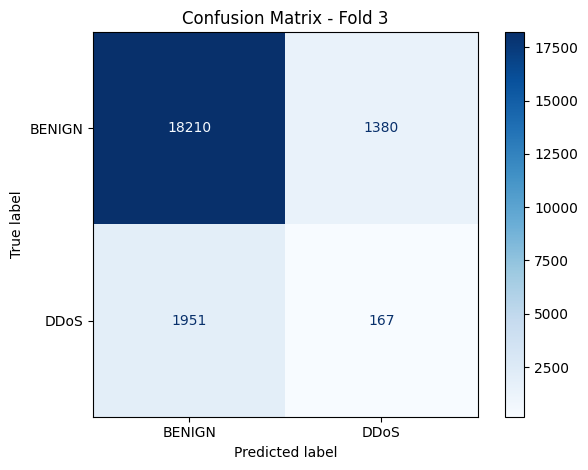


Fold 4 Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     19573
           1       0.14      0.10      0.11      2135

    accuracy                           0.85     21708
   macro avg       0.52      0.52      0.52     21708
weighted avg       0.83      0.85      0.84     21708



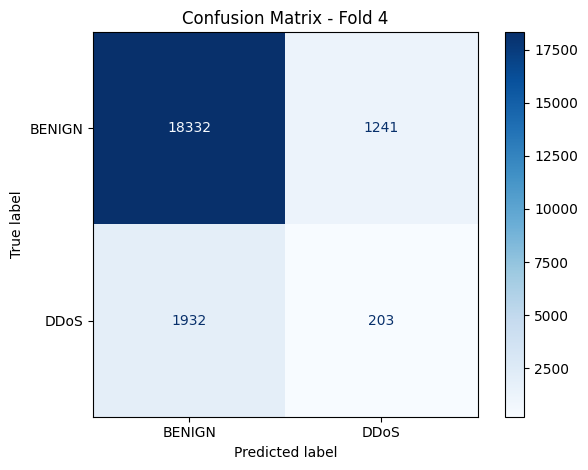


Fold 5 Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     19495
           1       0.13      0.09      0.10      2213

    accuracy                           0.84     21708
   macro avg       0.51      0.51      0.51     21708
weighted avg       0.82      0.84      0.83     21708



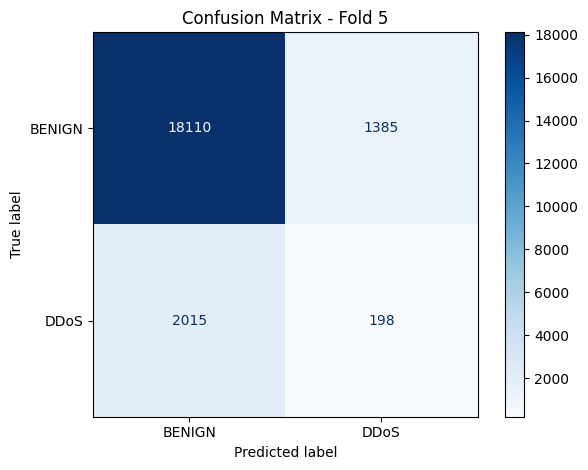


[Contamination 0.07] Avg Precision: 0.8255, Avg Recall: 0.8485, Avg F1: 0.8364

=== 5-Fold CV with Contamination = 0.1 ===

Fold 1 Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     19544
           1       0.11      0.12      0.12      2164

    accuracy                           0.82     21708
   macro avg       0.51      0.51      0.51     21708
weighted avg       0.82      0.82      0.82     21708



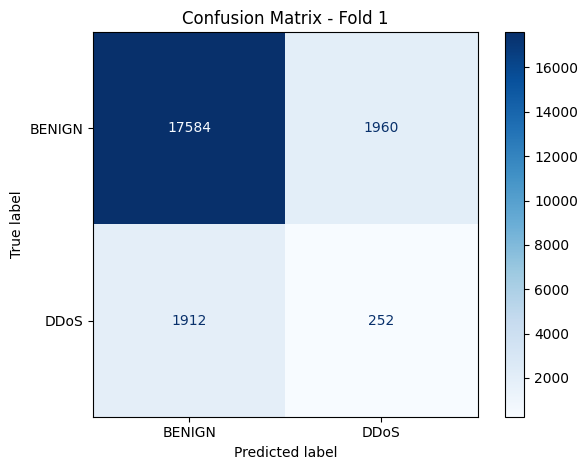


Fold 2 Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     19484
           1       0.16      0.15      0.15      2224

    accuracy                           0.83     21708
   macro avg       0.53      0.53      0.53     21708
weighted avg       0.83      0.83      0.83     21708



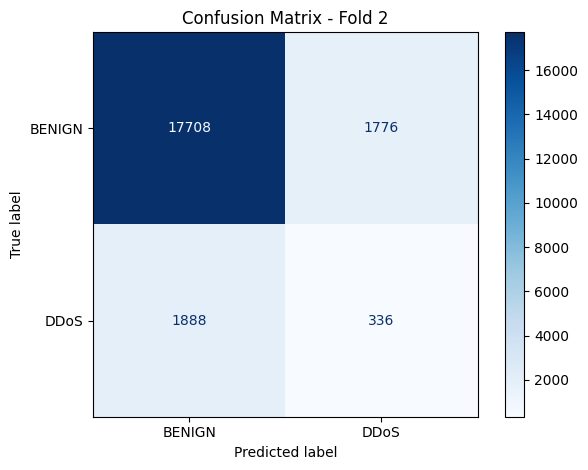


Fold 3 Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     19590
           1       0.14      0.14      0.14      2118

    accuracy                           0.83     21708
   macro avg       0.52      0.52      0.52     21708
weighted avg       0.83      0.83      0.83     21708



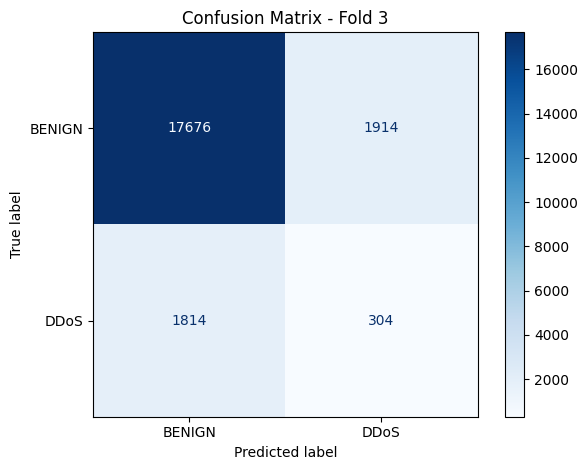


Fold 4 Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     19573
           1       0.14      0.14      0.14      2135

    accuracy                           0.83     21708
   macro avg       0.52      0.52      0.52     21708
weighted avg       0.83      0.83      0.83     21708



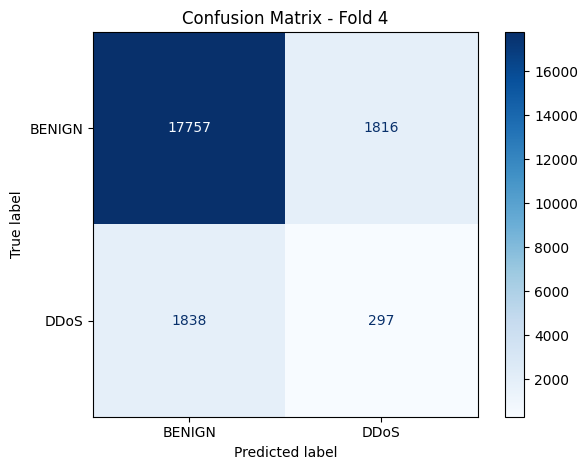


Fold 5 Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     19495
           1       0.15      0.16      0.16      2213

    accuracy                           0.83     21708
   macro avg       0.53      0.53      0.53     21708
weighted avg       0.83      0.83      0.83     21708



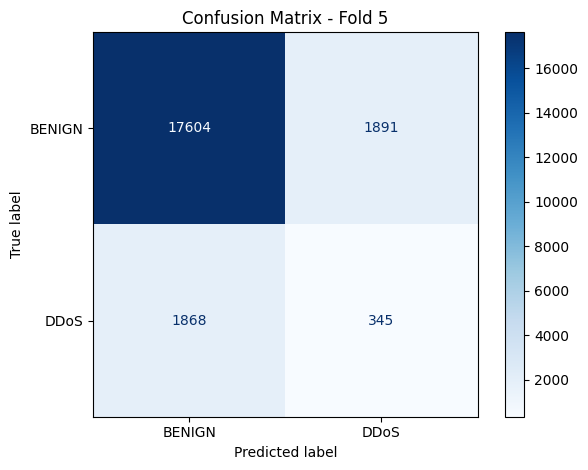


[Contamination 0.1] Avg Precision: 0.8282, Avg Recall: 0.8279, Avg F1: 0.8281

=== 5-Fold CV with Contamination = 0.12 ===

Fold 1 Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     19544
           1       0.11      0.14      0.13      2164

    accuracy                           0.81     21708
   macro avg       0.51      0.51      0.51     21708
weighted avg       0.82      0.81      0.82     21708



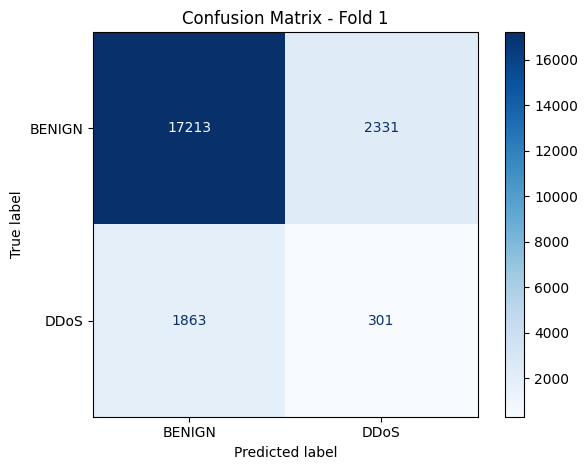


Fold 2 Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90     19484
           1       0.15      0.17      0.16      2224

    accuracy                           0.82     21708
   macro avg       0.53      0.53      0.53     21708
weighted avg       0.83      0.82      0.82     21708



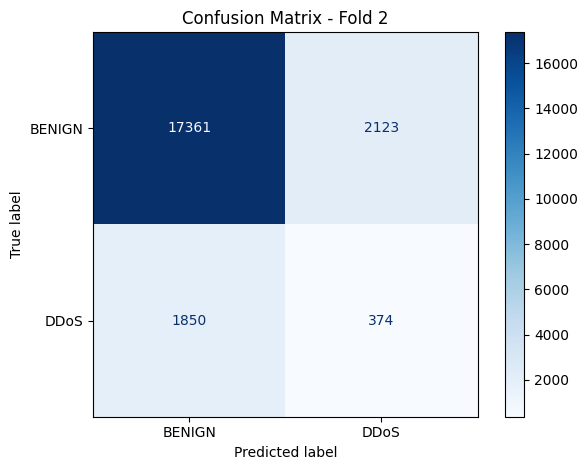


Fold 3 Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89     19590
           1       0.13      0.17      0.15      2118

    accuracy                           0.81     21708
   macro avg       0.52      0.52      0.52     21708
weighted avg       0.83      0.81      0.82     21708



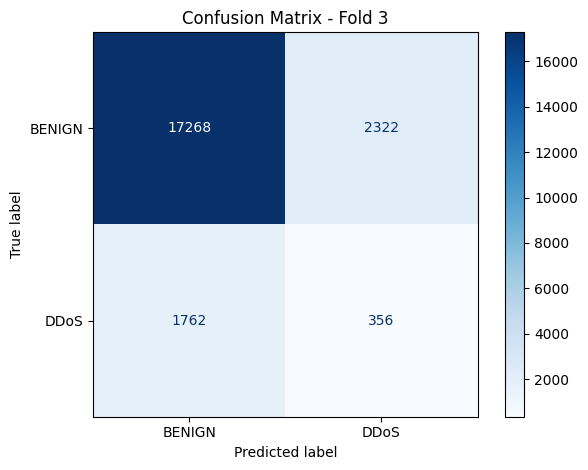


Fold 4 Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90     19573
           1       0.14      0.17      0.15      2135

    accuracy                           0.82     21708
   macro avg       0.52      0.53      0.53     21708
weighted avg       0.83      0.82      0.82     21708



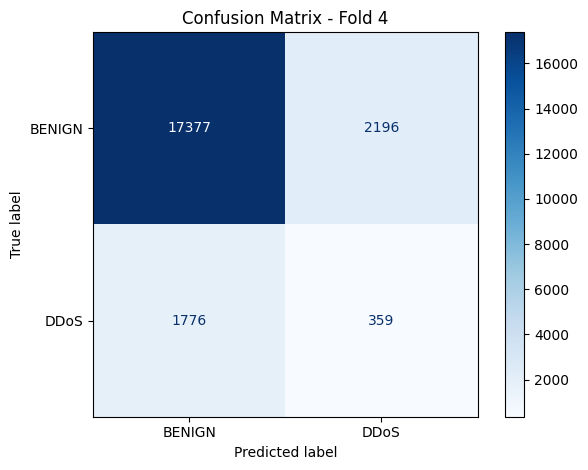


Fold 5 Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89     19495
           1       0.15      0.19      0.17      2213

    accuracy                           0.81     21708
   macro avg       0.53      0.54      0.53     21708
weighted avg       0.83      0.81      0.82     21708



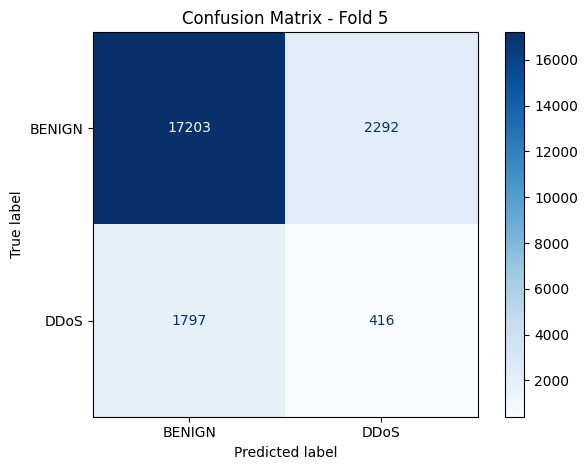


[Contamination 0.12] Avg Precision: 0.8285, Avg Recall: 0.8129, Avg F1: 0.8205


In [27]:
from sklearn.model_selection import KFold
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

contamination_values = [0.03, 0.05, 0.07, 0.10, 0.12]

for contamination in contamination_values:
    print(f"\n=== 5-Fold CV with Contamination = {contamination} ===")

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    all_reports = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(features_scaled)):
        X_train_cv, X_val_cv = features_scaled[train_idx], features_scaled[val_idx]
        y_val_cv = y_encoded[val_idx]

        # Optional: scale inside loop to prevent leakage
        scaler = StandardScaler()
        X_train_cv = scaler.fit_transform(X_train_cv)
        X_val_cv = scaler.transform(X_val_cv)

        model = IsolationForest(contamination=contamination, random_state=42)
        model.fit(X_train_cv)

        preds = model.predict(X_val_cv)
        preds = np.where(preds == -1, 1, 0)

        print(f"\nFold {fold + 1} Report:")
        print(classification_report(y_val_cv, preds))

        cm = confusion_matrix(y_val_cv, preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BENIGN', 'DDoS'])
        disp.plot(cmap='Blues', values_format='d')
        plt.title(f'Confusion Matrix - Fold {fold + 1}')
        plt.grid(False)
        plt.tight_layout()
        plt.show()

        all_reports.append(classification_report(y_val_cv, preds, output_dict=True))

    # Average scores
    avg_precision = np.mean([r['weighted avg']['precision'] for r in all_reports])
    avg_recall = np.mean([r['weighted avg']['recall'] for r in all_reports])
    avg_f1 = np.mean([r['weighted avg']['f1-score'] for r in all_reports])

    print(f"\n[Contamination {contamination}] Avg Precision: {avg_precision:.4f}, Avg Recall: {avg_recall:.4f}, Avg F1: {avg_f1:.4f}")


In [1]:
from sklearn.model_selection import KFold
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Split the full dataset into benign and DDoS parts
X_all = features_scaled
y_all = y_encoded
labels = data['Label'].values

# Get only BENIGN samples for training
X_benign = X_all[labels == 'BENIGN']
y_benign = y_all[labels == 'BENIGN']

# Get only DDoS samples for validation
X_ddos = X_all[labels != 'BENIGN']
y_ddos = y_all[labels != 'BENIGN']

# K-Fold over the DDoS set only
kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_reports = []

print("Training ONLY on BENIGN samples, validating with DDoS + fresh BENIGN samples...\n")

for fold, (ddos_train_idx, ddos_val_idx) in enumerate(kf.split(X_ddos)):
    # Training: all BENIGN only
    X_train = X_benign

    # Validation set: use part of DDoS + same amount of fresh BENIGN
    X_val_ddos = X_ddos[ddos_val_idx]
    y_val_ddos = y_ddos[ddos_val_idx]

    # Sample equal number of BENIGN for balance
    np.random.seed(fold)
    benign_sample_idx = np.random.choice(X_benign.shape[0], size=X_val_ddos.shape[0], replace=False)
    X_val_benign = X_benign[benign_sample_idx]
    y_val_benign = np.zeros(X_val_benign.shape[0])

    # Combine BENIGN + DDoS for validation
    X_val = np.vstack((X_val_benign, X_val_ddos))
    y_val = np.concatenate((y_val_benign, y_val_ddos))

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Train Isolation Forest
    model = IsolationForest(contamination=0.03, random_state=42)
    model.fit(X_train)

    preds = model.predict(X_val)
    preds = np.where(preds == -1, 1, 0)  # -1 → anomaly (DDoS), 1 → normal (BENIGN)

    print(f"\nFold {fold + 1} Report:")
    print(classification_report(y_val, preds))

    cm = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BENIGN', 'DDoS'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    all_reports.append(classification_report(y_val, preds, output_dict=True))

# Report averages
avg_f1 = np.mean([r['weighted avg']['f1-score'] for r in all_reports])
avg_recall = np.mean([r['weighted avg']['recall'] for r in all_reports])
avg_precision = np.mean([r['weighted avg']['precision'] for r in all_reports])

print(f"\n=== Final Averages ===")
print(f"Avg Precision: {avg_precision:.4f}")
print(f"Avg Recall:    {avg_recall:.4f}")
print(f"Avg F1-Score:  {avg_f1:.4f}")


NameError: name 'features_scaled' is not defined